In [14]:
### Build A Basic Chatbot

In [15]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from typing import Annotated

In [16]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [17]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [18]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="qwen/qwen3-32b")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000258A2DAC8F0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000258A2DAEAE0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [19]:
def chatbot(state:State):
    return {"messages":llm.invoke(state["messages"])}

In [20]:
graph_builder=StateGraph(State) 
graph_builder.add_node("chatbot",chatbot)
graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)
graph=graph_builder.compile()

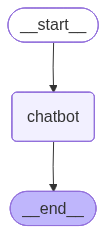

In [21]:
from IPython.display import Image,display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [22]:
response=graph.invoke({"messages":"hii"})
response["messages"][-1].content

'<think>\nOkay, the user sent "hii". That\'s a casual greeting. I should respond in a friendly and welcoming way. Maybe add an emoji to keep it light. Let me check if there\'s anything else they might need. Since they just said hi, perhaps ask how I can assist them. Keep the tone positive and open. Alright, something like "Hi! 😊 How can I assist you today?" That should work.\n</think>\n\nHi! 😊 How can I assist you today?'

##ChatBot with Tools


In [23]:
from langchain_tavily  import TavilySearch

tool= TavilySearch(max_results=2)
tool.invoke("who is vaibhav singh")

{'query': 'who is vaibhav singh',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://en.wikipedia.org/wiki/Vaibhav_Singh_Yadav',
   'title': 'Vaibhav Singh Yadav - Wikipedia',
   'content': '# Vaibhav Singh Yadav. | Vaibhav Singh Yadav at Pattaya in 2019 | |. | Weight\xa0class "Weight class (boxing)") | Welterweight |. **Vaibhav Singh Yadav** (also known as **Ahir Boxer** ) is an Indian boxer from New Delhi. He became World Boxing Council (WBC) Asia silver welterweight champion after defeating Thailand\'s Fahpetch Singmanassak in 2019. Yadav is the first Indian unified titles champion holder. He won this title after defeating Thailand\'s boxer Phongsathon Sompol by a 3rd-round knockout. He won his American debut against William Parra Smith. He trains out of the Nonantum Boxing Club in Newton, MA and resides in Delhi, India. ### Performance in Pro Boxing. ### Total Numbers of Pro Fights. In 2022 Vaibhav Singh Yadav was signed by LFG Boxing Manage

In [24]:
def multiply(a:int,b:int)->int:
     """Calculates the gross salary including bonuses."""
     return a*b

In [25]:
tools=[tool,multiply]
llm_bind_with_tools=llm.bind_tools(tools)


In [31]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode,tools_condition

graph_builder=StateGraph(State)

def llm_tool_call(state:State):
    return {"messages":llm_bind_with_tools.invoke(state["messages"])}

graph_builder.add_node("llm_tool_call",llm_tool_call)
graph_builder.add_node("tools",ToolNode(tools))

graph_builder.add_edge(START,"llm_tool_call")
graph_builder.add_conditional_edges("llm_tool_call",tools_condition)
graph_builder.add_edge("tools",END)

graph=graph_builder.compile()




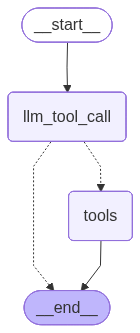

In [32]:
from IPython.display import display,Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [ ]:
response=graph.invoke({"messages":"what is india smallest distrct and what will be output of 15 * 15"})


{'messages': [HumanMessage(content='what is india smallest distrct and what will be output of 15 * 15', additional_kwargs={}, response_metadata={}, id='77d9974e-c73c-4159-a821-65994f72605e'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, let\'s tackle the user\'s query. They have two parts: first, finding India\'s smallest district, and second, calculating 15 multiplied by 15.\n\nStarting with the first part about India\'s smallest district. I need to recall or find information on Indian districts. I remember that districts can vary by area. The user is asking for the smallest in terms of area. I think the smallest might be a district in a union territory, like Lakshadweep or Andaman and Nicobar, but I\'m not sure. Alternatively, maybe a district in a state like Goa or Kerala. I need to verify this. Since I don\'t have real-time data, I should use the provided tool, tavily_search, to search for "India\'s smallest district by area". The tool can fetch the latest

ReAct Architecture

In [36]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode,tools_condition

graph_builder=StateGraph(State)

def llm_tool_call(state:State):
    return {"messages":llm_bind_with_tools.invoke(state["messages"])}

graph_builder.add_node("llm_tool_call",llm_tool_call)
graph_builder.add_node("tools",ToolNode(tools))

graph_builder.add_edge(START,"llm_tool_call")
graph_builder.add_conditional_edges("llm_tool_call",tools_condition)
graph_builder.add_edge("tools","llm_tool_call")
graph =graph_builder.compile()

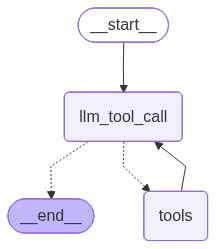

In [37]:
from IPython.display import display,Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass